In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/content/athlete_events.csv")
region_df = pd.read_csv("/content/noc_regions.csv")

In [4]:
df.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN
271115,135571,Tomasz Ireneusz ya,M,34.0,185.0,96.0,Poland,POL,2002 Winter,2002,Winter,Salt Lake City,Bobsleigh,Bobsleigh Men's Four,NaN


In [5]:
df.shape

(271116, 15)

In [6]:
df = df[df['Season'] == 'Summer']

In [7]:
df.shape

(222552, 15)

In [8]:
region_df.tail()

,NOC,region,notes
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN
229,ZIM,Zimbabwe,NaN


In [9]:
df = df.merge(region_df,on='NOC',how='left')

In [10]:
df.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
222547,135565,Fernando scar Zylberberg,M,27.0,168.0,76.0,Argentina,ARG,2004 Summer,2004,Summer,Athina,Hockey,Hockey Men's Hockey,NaN,Argentina,NaN
222548,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972 Summer,1972,Summer,Munich,Football,Football Men's Football,NaN,USA,NaN
222549,135567,Aleksandr Viktorovich Zyuzin,M,24.0,183.0,72.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN
222550,135567,Aleksandr Viktorovich Zyuzin,M,28.0,183.0,72.0,Russia,RUS,2004 Summer,2004,Summer,Athina,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN
222551,135568,Olga Igorevna Zyuzkova,F,33.0,171.0,69.0,Belarus,BLR,2016 Summer,2016,Summer,Rio de Janeiro,Basketball,Basketball Women's Basketball,NaN,Belarus,NaN


In [11]:
df['region'].unique().shape

(206,)

In [12]:
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,9189
Height,51857
Weight,53854
Team,0
NOC,0
Games,0
Year,0


In [13]:
df.duplicated().sum()

np.int64(1385)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['Medal'].value_counts()

,count
Medal,
Gold,11456
Bronze,11409
Silver,11212


In [17]:
pd.get_dummies(df['Medal'],dtype=int)

,Bronze,Gold,Silver
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,0
4,0,0,0
...,...,...,...
222547,0,0,0
222548,0,0,0
222549,0,0,0
222550,0,0,0


In [18]:
df.shape

(221167, 17)

In [19]:
df = pd.concat([df,pd.get_dummies(df['Medal'],dtype=int)],axis = 1)

In [20]:
df.groupby('NOC').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

,NOC,Gold,Silver,Bronze
0,USA,2472,1333,1197
1,URS,832,635,596
2,GBR,635,729,620
3,GER,592,538,649
4,ITA,518,474,454
...,...,...,...,...
225,WIF,0,0,5
226,YEM,0,0,0
227,YAR,0,0,0
228,YMD,0,0,0


In [21]:
medal_tally = df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])

In [22]:
medal_tally.groupby('NOC').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

,NOC,Gold,Silver,Bronze
0,USA,1035,802,708
1,URS,394,317,294
2,GBR,278,317,300
3,GER,235,261,283
4,FRA,234,256,287
...,...,...,...,...
225,WIF,0,0,2
226,YEM,0,0,0
227,YAR,0,0,0
228,YMD,0,0,0


In [23]:
medal_tally[medal_tally['NOC'] == 'IND']

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
436,281,S. Abdul Hamid,M,NaN,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Athletics,Athletics Men's 110 metres Hurdles,NaN,India,NaN,0,0,0
437,281,S. Abdul Hamid,M,NaN,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Athletics,Athletics Men's 400 metres Hurdles,NaN,India,NaN,0,0,0
790,512,Shiny Kurisingal Abraham-Wilson,F,19.0,167.0,53.0,India,IND,1984 Summer,1984,Summer,Los Angeles,Athletics,Athletics Women's 800 metres,NaN,India,NaN,0,0,0
791,512,Shiny Kurisingal Abraham-Wilson,F,19.0,167.0,53.0,India,IND,1984 Summer,1984,Summer,Los Angeles,Athletics,Athletics Women's 4 x 400 metres Relay,NaN,India,NaN,0,0,0
792,512,Shiny Kurisingal Abraham-Wilson,F,23.0,167.0,53.0,India,IND,1988 Summer,1988,Summer,Seoul,Athletics,Athletics Women's 800 metres,NaN,India,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216942,132143,Vikas Krishan Yadav,M,24.0,177.0,69.0,India,IND,2016 Summer,2016,Summer,Rio de Janeiro,Boxing,Boxing Men's Middleweight,NaN,India,NaN,0,0,0
216985,132177,Mohammad Anas Yahiya,M,21.0,177.0,69.0,India,IND,2016 Summer,2016,Summer,Rio de Janeiro,Athletics,Athletics Men's 400 metres,NaN,India,NaN,0,0,0
218411,133029,"Thyadathuvilla Chandrapillai ""T. C."" Yohannan",M,29.0,174.0,62.0,India,IND,1976 Summer,1976,Summer,Montreal,Athletics,Athletics Men's Long Jump,NaN,India,NaN,0,0,0
222416,135480,Geeta Zutshi,F,23.0,167.0,51.0,India,IND,1980 Summer,1980,Summer,Moskva,Athletics,Athletics Women's 800 metres,NaN,India,NaN,0,0,0


In [24]:
years = df['Year'].unique().tolist()

In [25]:
years.sort()

In [26]:
years.insert(0,'Overall')

In [27]:
years

['Overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [28]:
country = np.unique(df['region'].dropna().values).tolist()

In [29]:
country.sort()

In [30]:
country.insert(0,'Overall')

In [31]:
def fetch_medal_tally(df,year,country):
  medal_df = df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])
  flag = 0
  if year == 'Overall' and country == 'Overall':
    temp_df = medal_df
  if year == 'Overall' and country != 'Overall':
    temp_df = medal_df[medal_df['region'] == country]
    flag = 1
  if year != 'Overall' and country == 'Overall':
    temp_df = medal_df[medal_df['Year'] == int(year)]
  if year != 'Overall' and country != 'Overall':
    temp_df = medal_df[(medal_df['Year'] == int(year)) & (medal_df['region'] == country)]

  if flag == 1:
    x = temp_df.groupby('Year').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()
  else:
    x = temp_df.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

  x['total'] = x['Gold'] + x['Silver'] + x['Bronze']

  print(x)

In [32]:
medal_df = df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])

In [33]:
fetch_medal_tally(medal_df,year = 'Overall', country = 'France')

    Year  Gold  Silver  Bronze  total
0   1900    29      41      39    109
1   1906    15      10      16     41
2   1996    15       7      15     37
3   1924    14      14      12     40
4   2000    13      14      11     38
5   2012    11      11      13     35
6   2004    11       9      13     33
7   1932    11       5       4     20
8   1948    11       6      15     32
9   2016    10      18      14     42
10  1920     9      20      13     42
11  1992     8       5      16     29
12  1928     7      12       6     25
13  1912     7       5       3     15
14  1936     7       6       6     19
15  1968     7       3       5     15
16  2008     7      16      18     41
17  1980     6       5       3     14
18  1988     6       4       6     16
19  1952     6       6       6     18
20  1896     5       4       2     11
21  1984     5       7      16     28
22  1908     5       5       9     19
23  1956     4       4       6     14
24  1972     2       4       7     13
25  1976    

In [34]:
df['Year'].unique().shape[0] - 1

28

In [35]:
df['City'].unique()

array(['Barcelona', 'London', 'Antwerpen', 'Paris', 'Los Angeles',
       'Helsinki', 'Sydney', 'Atlanta', 'Stockholm', 'Beijing',
       'Rio de Janeiro', 'Athina', 'Mexico City', 'Munich', 'Seoul',
       'Berlin', 'Melbourne', 'Roma', 'Amsterdam', 'Montreal', 'Moskva',
       'Tokyo', 'St. Louis'], dtype=object)

In [36]:
df['Sport'].unique()

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

In [37]:
df['Event'].unique().shape

(651,)

In [38]:
df['Name'].unique().shape

(116122,)

In [39]:
df['region'].unique().shape

(206,)

In [40]:
nations_over_time = df.drop_duplicates(['Year','region'])['Year'].value_counts().reset_index().sort_values('Year')

In [41]:
nations_over_time.rename(columns= {'Year' : 'Edition', 'count' : 'No of Countries'},inplace = True)

In [42]:
nations_over_time

,Edition,No of Countries
28,1896,12
22,1900,31
27,1904,14
26,1906,20
25,1908,22
23,1912,29
24,1920,29
21,1924,45
20,1928,46
19,1932,47


In [43]:
import plotly.express as px

In [44]:
fig = px.line(nations_over_time, x = "Edition", y = 'No of Countries')

In [45]:
fig.show()

In [46]:
df.drop_duplicates(['Year','Event'])['Year'].value_counts().reset_index().sort_values('Year')

,Year,count
28,1896,43
26,1900,90
25,1904,95
27,1906,74
23,1908,109
24,1912,107
14,1920,158
20,1924,131
22,1928,122
21,1932,131


In [47]:
import seaborn as sns

In [48]:
x = df.drop_duplicates(['Year','Sport','Event'])

<Axes: xlabel='Year', ylabel='Sport'>

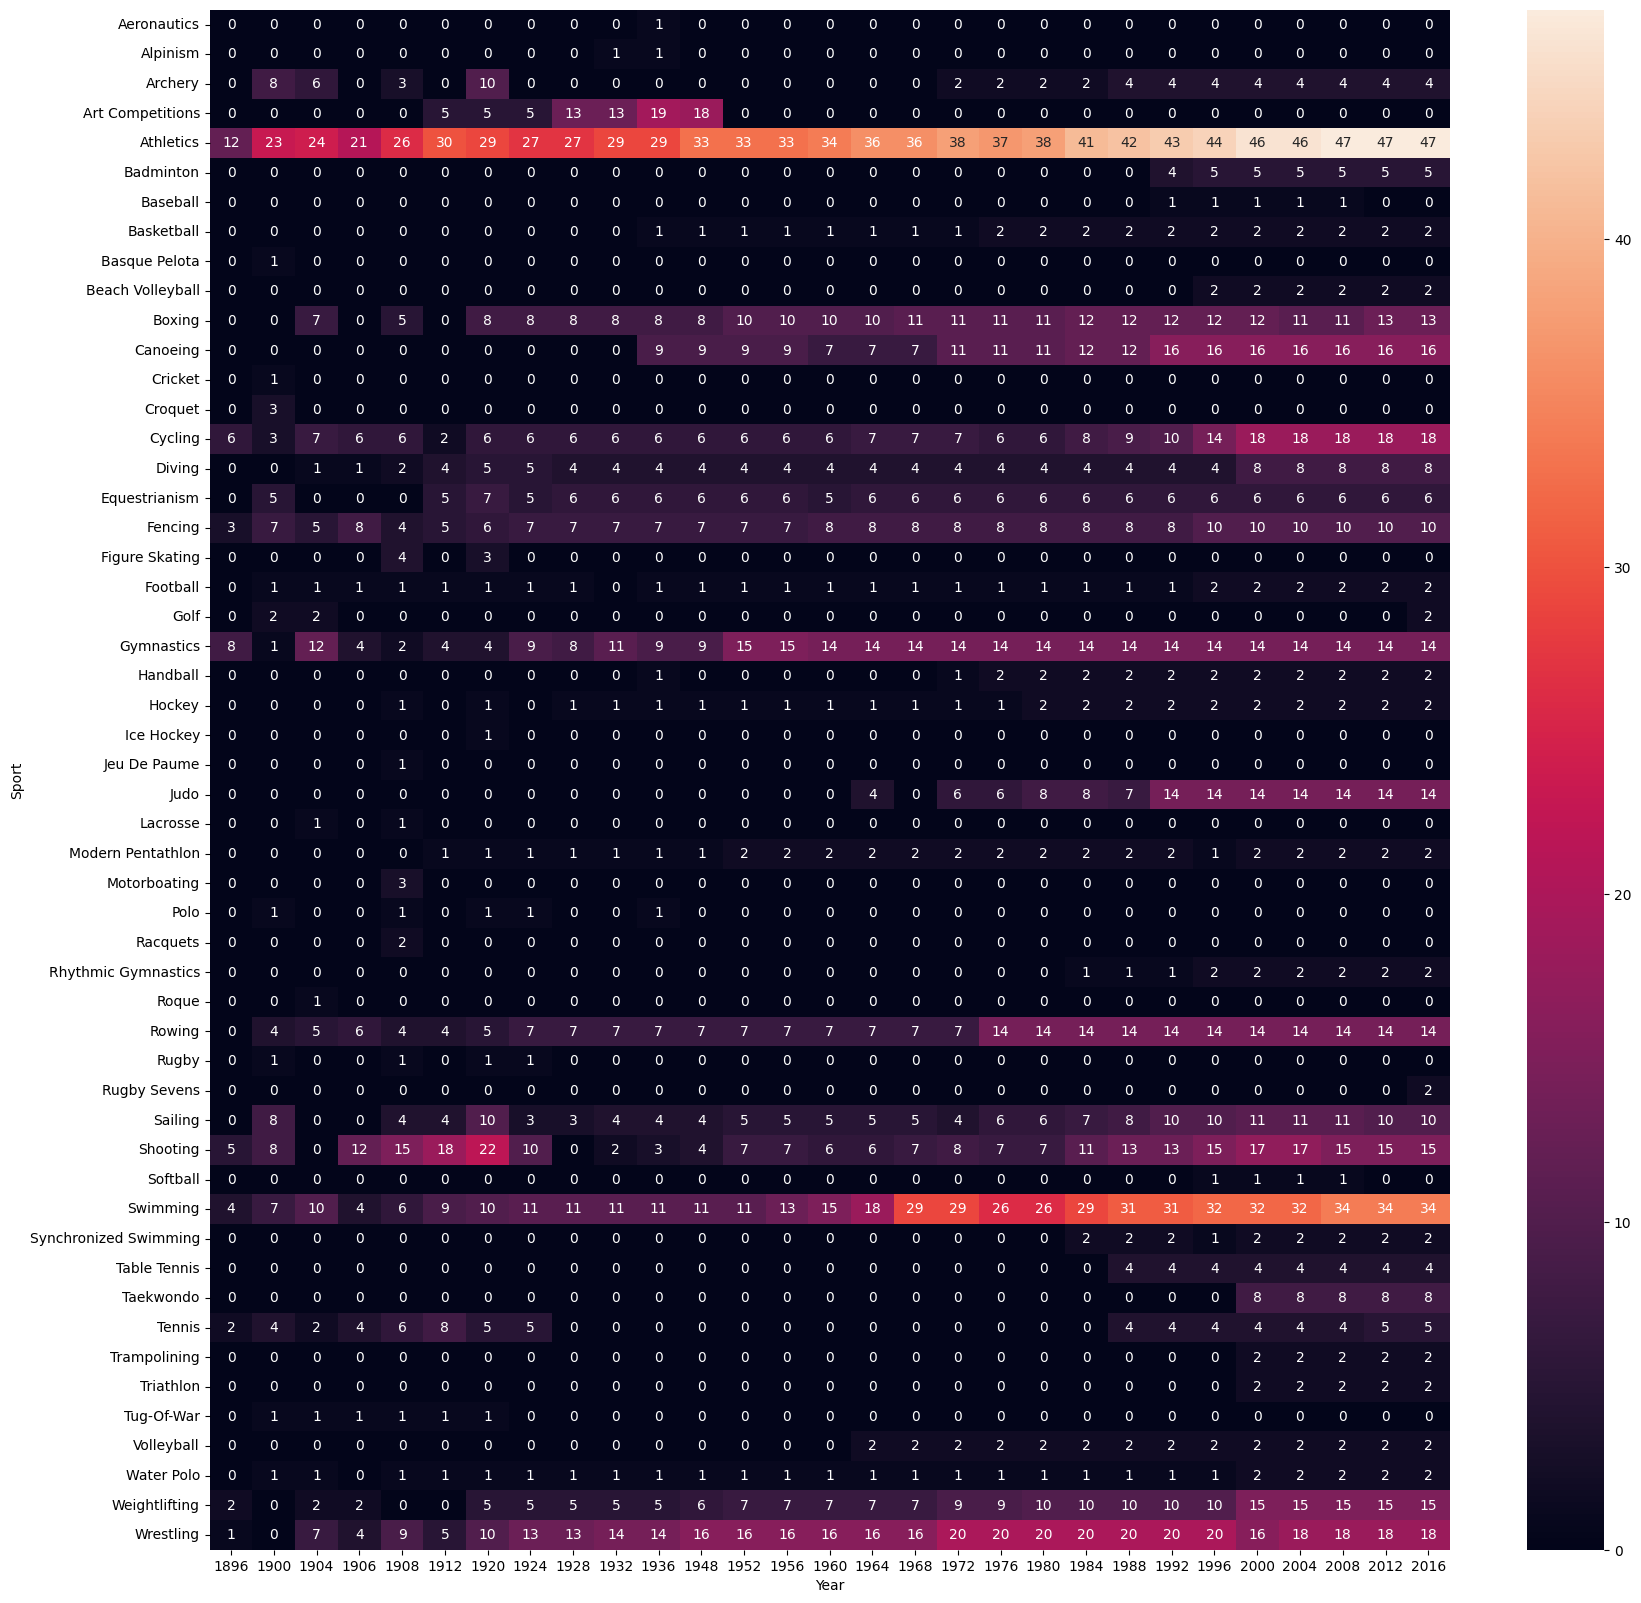

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (20,20))
sns.heatmap(x.pivot_table(index = 'Sport',columns= 'Year', values = 'Event',aggfunc='count').fillna(0).astype('int'),annot=True)

In [50]:
x = df.drop_duplicates(['Year','Sport','Event'])

In [51]:
x.pivot_table(index = 'Sport',columns = 'Year',values = 'Event',aggfunc = 'count').fillna(0).astype('int')

Year,1896,1900,1904,1906,1908,1912,1920,1924,1928,1932,...,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016
Sport,,,,,,,,,,,,,,,,,,,,,
Aeronautics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alpinism,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Archery,0,8,6,0,3,0,10,0,0,0,...,2,2,4,4,4,4,4,4,4,4
Art Competitions,0,0,0,0,0,5,5,5,13,13,...,0,0,0,0,0,0,0,0,0,0
Athletics,12,23,24,21,26,30,29,27,27,29,...,38,41,42,43,44,46,46,47,47,47
Badminton,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,5,5,5,5,5,5
Baseball,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,0,0
Basketball,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
Basque Pelota,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
# Count medals per player
top_players = (
    df.dropna(subset=['Medal'])
      .groupby('Name')
      .size()
      .reset_index(name='Medal_Count')
      .sort_values('Medal_Count', ascending=False)
      .head(10)
)

# Merge back to get Sport & region
result = (
    top_players
      .merge(df[['Name', 'Sport', 'region']], on='Name', how='left')
      .drop_duplicates('Name')
)

result

,Name,Medal_Count,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Edoardo Mangiarotti,13,Fencing,Italy
87,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
111,Takashi Ono,13,Gymnastics,Japan
144,Sawao Kato,12,Gymnastics,Japan
168,Ryan Steven Lochte,12,Swimming,USA
182,Birgit Fischer-Schmidt,12,Canoeing,Germany
195,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA


In [53]:
def most_successful(df,sport):
  temp_df = df.dropna(subset = ['Medal'])
  if sport != 'Overall':
    temp_df = temp_df[temp_df['Sport'] == sport]

  return temp_df['Name'].value_counts().reset_index().head(15).merge(df,left_on='index',right_on='Name',how='left')

In [54]:
def most_successful(df, sport):
  temp_df = df.dropna(subset=['Medal'])
  if sport != 'Overall':
    temp_df = temp_df[temp_df['Sport'] == sport]

  # Calculate medal counts for each athlete
  athlete_medal_counts = temp_df['Name'].value_counts().reset_index()
  # Rename columns for clarity; the first column is 'Name' due to the series's name
  athlete_medal_counts.columns = ['Name', 'Medal_Count']

  # Select the top 15 athletes
  top_15_athletes = athlete_medal_counts.head(15)

  # Merge with a subset of the original df to get Sport and region information
  # This merge will include duplicates if an athlete participated in multiple sports or regions
  merged_info = top_15_athletes.merge(df[['Name', 'Sport', 'region']], on='Name', how='left')

  # Drop duplicates to ensure each athlete appears only once with a representative Sport and region
  # The specific Sport and region will be the first one encountered during the merge for that athlete.
  final_result = merged_info.drop_duplicates(subset=['Name'])

  return final_result

most_successful(df,'Overall')

,Name,Medal_Count,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
97,Takashi Ono,13,Gymnastics,Japan
130,Edoardo Mangiarotti,13,Fencing,Italy
144,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
157,Birgit Fischer-Schmidt,12,Canoeing,Germany
170,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
187,Ryan Steven Lochte,12,Swimming,USA


In [55]:
def most_successful(df, sport):
  temp_df = df.dropna(subset=['Medal'])
  if sport != 'Overall':
    temp_df = temp_df[temp_df['Sport'] == sport]

  # Calculate medal counts for each athlete
  athlete_medal_counts = temp_df['Name'].value_counts().reset_index()
  # Rename columns for clarity; the first column is 'Name' due to the series's name
  athlete_medal_counts.columns = ['Name', 'Medals']

  # Select the top 15 athletes
  top_15_athletes = athlete_medal_counts.head(15)

  # Merge with a subset of the original df to get Sport and region information
  # This merge will include duplicates if an athlete participated in multiple sports or regions
  merged_info = top_15_athletes.merge(df[['Name', 'Sport', 'region']], on='Name', how='left')

  # Drop duplicates to ensure each athlete appears only once with a representative Sport and region
  # The specific Sport and region will be the first one encountered during the merge for that athlete.
  final_result = merged_info.drop_duplicates(subset=['Name'])

  return final_result

most_successful(df,'Overall')

,Name,Medals,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
97,Takashi Ono,13,Gymnastics,Japan
130,Edoardo Mangiarotti,13,Fencing,Italy
144,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
157,Birgit Fischer-Schmidt,12,Canoeing,Germany
170,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
187,Ryan Steven Lochte,12,Swimming,USA


In [56]:
temp_df = df.dropna(subset=['Medal'])
temp_df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'],inplace=True)

/tmp/ipython-input-3249058805.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [57]:
new_df = temp_df[temp_df['region'] == 'India']
final_df = new_df.groupby('Year').count()['Medal'].reset_index()

In [58]:
fig = px.line(final_df, x = "Year", y = "Medal")
fig.show()

<Axes: xlabel='Year', ylabel='Sport'>

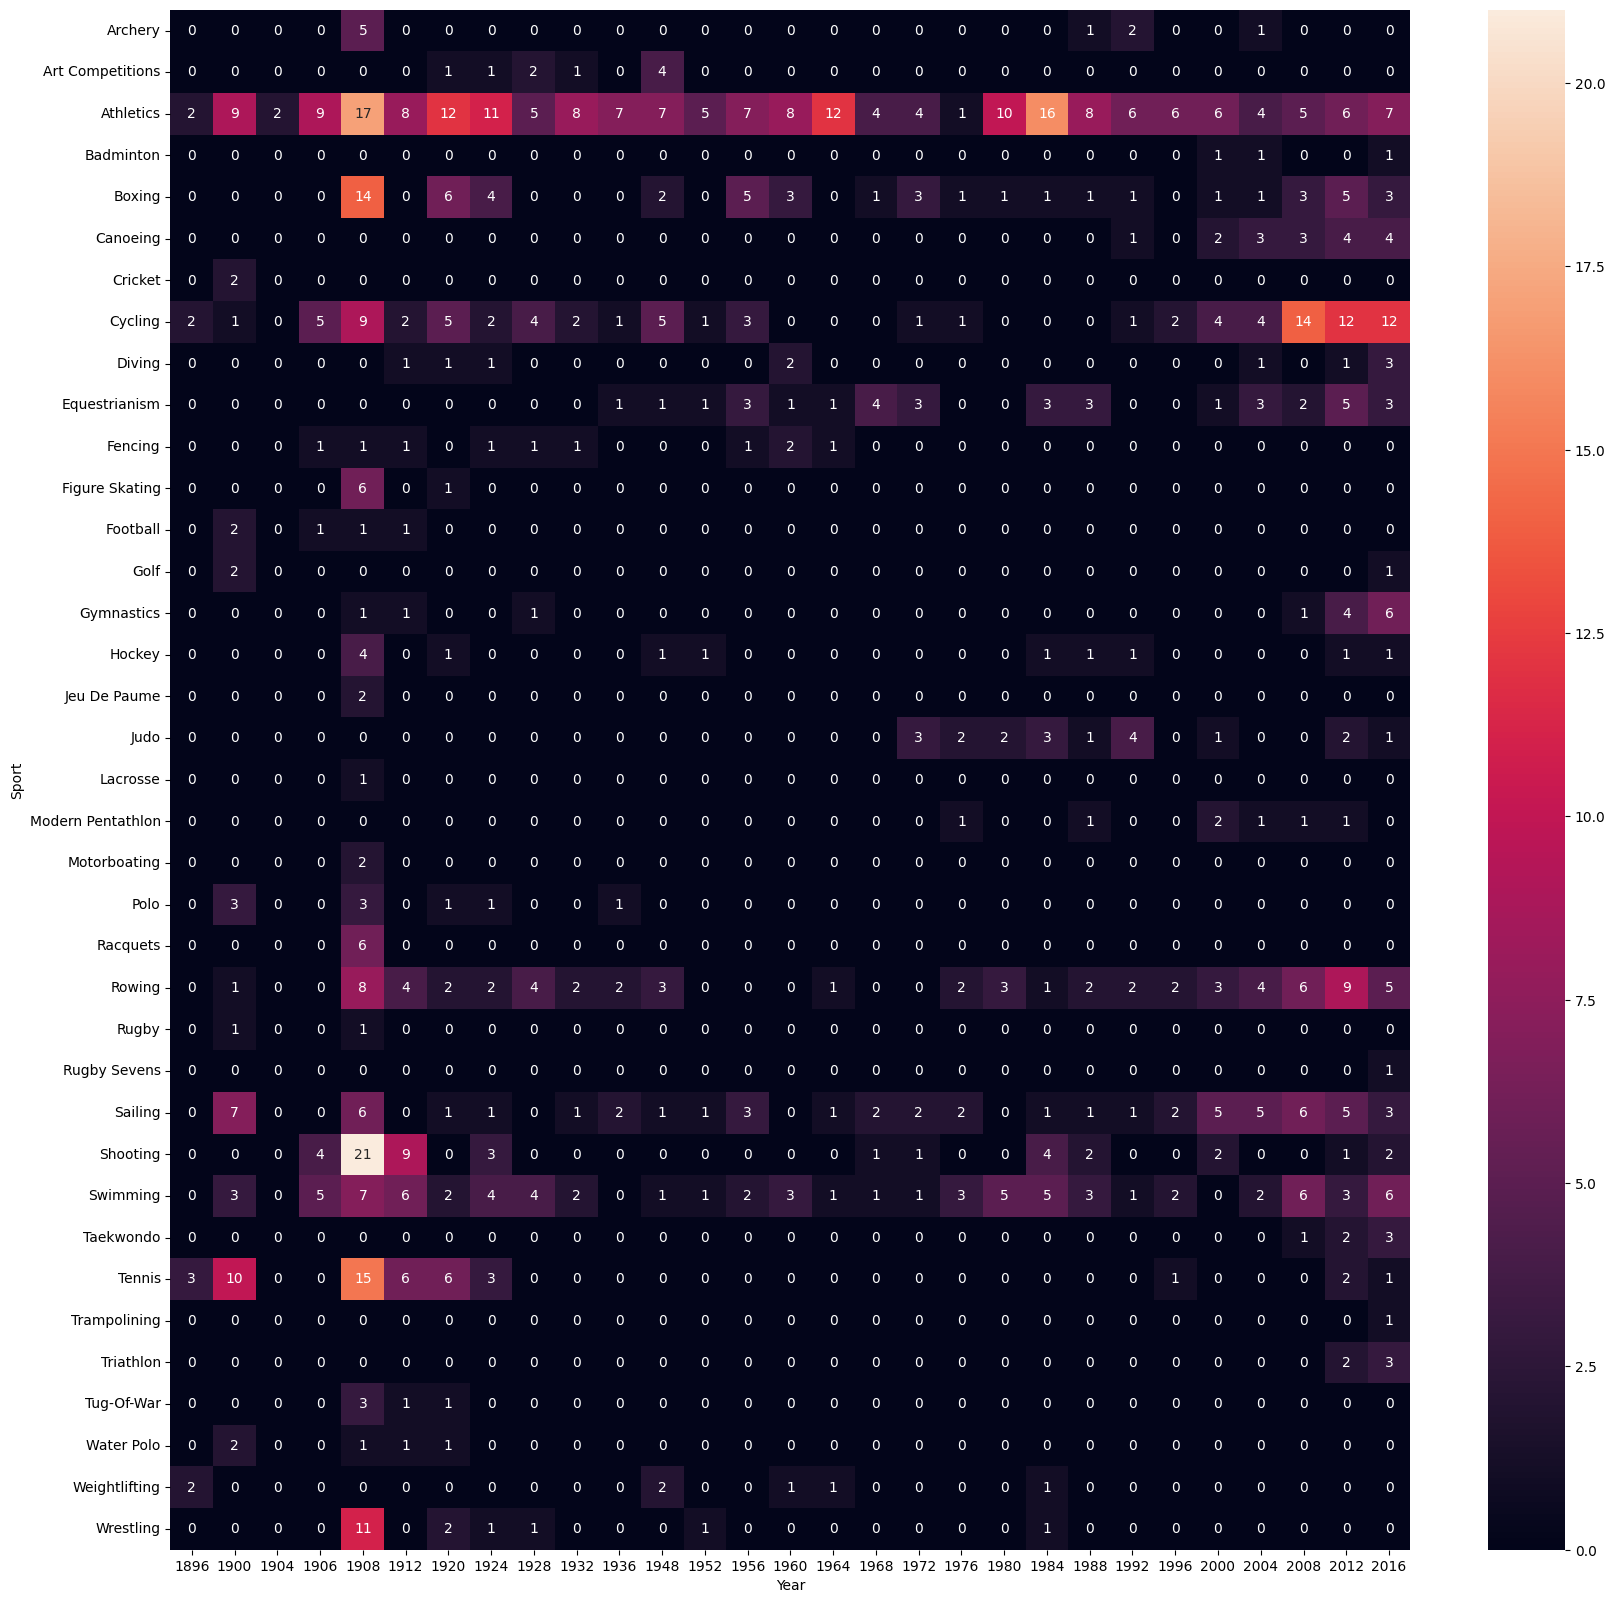

In [59]:
import matplotlib.pyplot as plt
new_df = temp_df[temp_df['region'] == 'UK']
plt.figure(figsize=(20,20))
sns.heatmap(new_df.pivot_table(index = 'Sport',columns='Year',values = 'Medal',aggfunc='count').fillna(0),annot=True)

In [60]:
def most_successful(df, country):

    temp_df = df.dropna(subset=['Medal'])
    temp_df = temp_df[temp_df['region'] == country]

    x = temp_df.groupby('Name').size().reset_index(name='Medals')

    x = x.sort_values(['Medals', 'Name'], ascending=[False, True]).head(15)

    x = x.merge(df[['Name','Sport']], on='Name', how='left') \
         .drop_duplicates('Name')

    return x

In [61]:
most_successful(df,'Jamaica')

,Name,Medals,Sport
0,Merlene Joyce Ottey-Page,9,Athletics
19,Usain St. Leo Bolt,8,Athletics
29,Veronica Angella Campbell-Brown,8,Athletics
40,Shelly-Ann Fraser-Pryce,6,Athletics
47,Arthur Stanley Wint,4,Athletics
53,"Donald O'Reilly ""Don"" Quarrie",4,Athletics
62,"Herbert Henry ""Herb"" McKenley",4,Athletics
68,Novlene Hilaire Williams-Mills,4,Athletics
75,Yohan Blake,4,Athletics
81,Beverly McDonald (-Stewart),3,Athletics


In [62]:
import plotly.figure_factory as ff

In [63]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0


In [64]:
athlete_df = df.drop_duplicates(subset=['Name','region'])

In [65]:
x1 = athlete_df['Age'].dropna()
x2 = athlete_df[athlete_df['Medal'] == 'Gold']['Age'].dropna()
x3 = athlete_df[athlete_df['Medal'] == 'Silver']['Age'].dropna()
x4 = athlete_df[athlete_df['Medal'] == 'Bronze']['Age'].dropna()

In [66]:
fig = ff.create_distplot([x1,x2,x3,x4],['Overall Age','Gold Medalist','Silver Medalist','Bronze Medalist'],show_hist=False,show_rug=False)
fig.show()

In [67]:
x=[]
name=[]
famous_sports = ['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
'Water Polo', 'Hockey', 'Rowing', 'Fencing',
'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
'Tennis', 'Golf', 'Softball', 'Archery',
'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
'Rhythmic Gymnastics', 'Rugby Sevens',
'Beach Volleyball', 'Triathlon', 'Rugby', 'Polo', 'Ice Hockey']
for sport in famous_sports:
  temp_df = athlete_df[athlete_df['Sport'] == sport]
  x.append(temp_df[temp_df['Medal'] == 'Gold']['Age'].dropna())
  name.append(sport)

In [68]:
fig = ff.create_distplot(x,name,show_hist=False,show_rug=False)
fig.update_layout(autosize=False,width=1000,height=600)
fig.show()

In [69]:
athlete_df['Medal'].fillna('No Medal',inplace = True)

/tmp/ipython-input-524805123.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





<Axes: xlabel='Weight', ylabel='Height'>

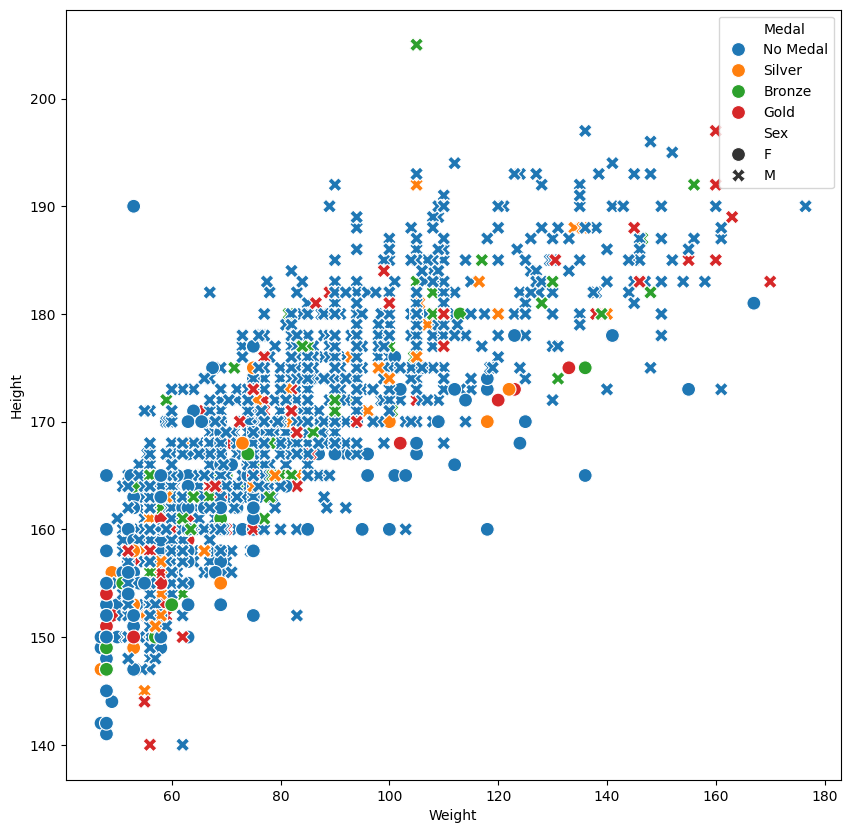

In [84]:
plt.figure(figsize=(10,10))
temp_df = athlete_df[athlete_df['Sport'] == 'Weightlifting']
sns.scatterplot(x=temp_df['Weight'],y=temp_df['Height'],hue=temp_df['Medal'],style = temp_df['Sex'],s=100)

In [85]:
men = athlete_df[athlete_df['Sex'] == 'M'].groupby('Year').count()['Name'].reset_index()
women = athlete_df[athlete_df['Sex'] == 'F'].groupby('Year').count()['Name'].reset_index()

In [90]:
final = men.merge(women,on='Year',how='left')
final.rename(columns={'Name_x' : 'Male','Name_y' : 'Female'},inplace=True)

In [92]:
final.fillna(0,inplace=True)

In [93]:
fig = px.line(final,x="Year",y=["Male","Female"])
fig.show()